In [1]:
import os
#os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
import sys
sys.path.append('cem-mil')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR/tiler')

import glob
from typing import Optional, Dict, Any, Tuple

import torch
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger
from sklearn.preprocessing import LabelEncoder
from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, f1_score, roc_auc_score
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


from arg_def import Args
from loader.tile_loader import TileDataset, MultinominalSampler

from cem_mil.models.cem_mil import ConceptEmbeddingModel
import cem_mil.train.utils as utils

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/home/verghese/.local/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages', 'cem-mil', '/SAN/colcc/Hormad1/projects/MINOTAUR', '/SAN/colcc/Hormad1/projects/MINOTAUR/tiler', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor', '/tmp/5548694.1.gpu.q/tmp27gjieqg']


In [3]:
pcanc_train_cohort = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/bin_stcanage_60surv_train_v2.csv')
cat_pcanc_train_cohort = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/cat_stcanage_60surv_train_cohort.csv')

In [4]:
#custom_id_order = list(cat_pcanc_train_cohort['ID'])
#pcanc_train_cohort['ID'] = pd.Categorical(pcanc_train_cohort['ID'], categories=custom_id_order, ordered=True)
#pcanc_train_cohort = pcanc_train_cohort.sort_values('ID')
cat_val_df = pd.read_csv('cat_val_ids.csv')
val_ids = list(cat_val_df['0'])

In [5]:
cat_val_df_2 = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/cat_val_ids.csv')
val_ids_2 = list(cat_val_df_2['0'])

In [6]:
set(val_ids) - set(val_ids_2)

set()

In [7]:
#had to remove cancer from stratification not enough data for each permutation
#pcanc_train_cohort['stratify_col'] = pcanc_train_cohort[binary_cpts].astype(str).agg('-'.join, axis=1)

##random_state=42
#train_df, val_df = train_test_split(
#    pcanc_train_cohort, 
#    test_size=0.2, 
#    #stratify=pcanc_train_cohort['stratify_col'], 
#    random_state=42
#)

#train, val = list(train_df['ID']), list(val_df['ID'])
pcanc_train_cohort['test'] = pcanc_train_cohort['ID'].apply(lambda x: 0 if x in val_ids else 1)


In [8]:
len(pcanc_train_cohort[pcanc_train_cohort['test']==0])

330

### Dataloaders

In [14]:
#DB_PATH = '/home/clinical-concepts/maracuja.clinical-concepts/data/features/t-selection/uni/baseline/'
DB_PATH = '/SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2'
#db_path = '/Users/k2030634/PhD/Isambard/data/features'

In [10]:
def get_dloaders(
        train_data,
        val_data,
        args: Any,
        ) -> Tuple[Optional[DataLoader], Optional[DataLoader]]:
        """
        Sets up the data loaders for training and validation.

        Args:
            args: Namespace, model arguments.
            with_data: Boolean, if True loads data.

        Returns:
            Tuple[DataLoader, DataLoader]: Train and validation data loaders.
        """
        db_paths = glob.glob(
            os.path.join(DB_PATH, 'features', '*')
            #os.path.join(db_path, '*')
        )

        #need to get correct number of dbs for weights
        #TODO remove from tileloader.py
        train_dbs = [
            p 
            for p in db_paths 
            for db in list(train_data['ID']) 
            if db==os.path.basename(p[:-4])
            ]
        
        train_weights = [1 for i in range(len(train_dbs))]
        
        mn_sampler = MultinominalSampler(
            train_weights, 
            len(train_dbs)
            )
        
        train_dataset = TileDataset(train_data, args.db_path, args.target, args.cpt_ids, args.bag_n)
        val_dataset = TileDataset(val_data, args.db_path, args.target, args.cpt_ids, args.bag_n)

        ##increase num of workers if not local
        train_dloader = DataLoader(
            train_dataset, 
            args.batch_size, 
            sampler = mn_sampler, 
            num_workers = 16,
            drop_last=True
            )

        #increase num of workers if not local
        val_dloader = DataLoader(
            val_dataset, 
            batch_size=4, 
            num_workers = 16)

        return train_dloader, val_dloader

In [11]:
num_workers = os.cpu_count()
print(f"Number of workers available: {num_workers}")

Number of workers available: 56


In [12]:
args = Args(DB_PATH)
train_data = pcanc_train_cohort[pcanc_train_cohort['test']==1]
val_data = pcanc_train_cohort[pcanc_train_cohort['test']==0]
print(len(val_data))
train_dloader, val_dloader = get_dloaders(train_data=train_data,val_data=val_data,args=args)

330
db_path /SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2
greg 1312
Loading 1311%num bags 1312
db_path /SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2
greg 330
Loading 329%num bags 330


### Training

In [20]:
import warnings
warnings.filterwarnings("ignore")
                        
import pytorch_lightning as pl
from cem_mil.models.cem_mil import ConceptEmbeddingModel 
from pytorch_lightning.callbacks import RichProgressBar


In [21]:
LOGS_PATH = '/SAN/colcc/Hormad1/analysis/minotaur/logs/job/'
OUT_PATH = '/SAN/colcc/Hormad1/analysis/minotaur/'
logger1 = TensorBoardLogger(LOGS_PATH, name='binary_test10_noweights')

In [22]:
attention_hook = utils.AttentionHook()
atten_callback = utils.SaveAttentionCallback(attention_hook=attention_hook)

In [23]:
t_accs, t_f1s, t_rocs = [], [], []
c_accs_lst, c_f1s_lst, c_roc_lst, concept_lst = [], [], [], []
names = []
cpt_class_weights = torch.ones(17)

In [24]:
args.batch = 32
args.bag_n

3000

In [25]:
for pre in [True]:
    for c_weight in [0.01]:
        for emb_size in [8]:
            for dropout in [0.3]:
                for attention in [attention_hook]:
                    for i in range(1):
                        #attention callback to log attention
                        a_text = 'attention' if attention is not None else 'att_'+str(None)
                        name = str(pre) + '_' + str(emb_size) + '_' + str(c_weight) + '_' + str(dropout) + '_' + a_text + '_' + str(i)
                        names.append(name)
                        print('type', args.categorical)

                        logger1 = TensorBoardLogger(LOGS_PATH, name=name)
                        cem_model = ConceptEmbeddingModel(
                          n_concepts=17, 
                          #concept_states = [4, 4],
                          n_tasks=1, 
                          h_dim = 1024,
                          pre_bn_mlp = pre,
                          emb_size=emb_size, 
                          embedding_activation="LeakyReLU",
                          concept_loss_weight=c_weight,
                          task_loss_weight = 1 ,
                          concept_class_weights=torch.tensor(cpt_class_weights),
                          dropout = dropout,
                          learning_rate=1e-3,  
                          optimizer="adam", 
                          c2y_model=None, 
                          attention_hook = attention_hook
                        ) 

                        trainer = pl.Trainer(
                            accelerator="gpu",
                            devices="auto", 
                            max_epochs=30,
                            check_val_every_n_epoch=30,
                            callbacks = [atten_callback],
                            enable_progress_bar=True,
                            logger=logger1
                        )

                        trainer.fit(cem_model, train_dloader, val_dloader)
                        x_test, y_test, c_test = [], [], []
                        for (x, y, c) in val_dloader:
                            x_test.append(x)
                            y_test.append(y)
                            c_test.append(c)

                        x_test = np.concatenate(x_test, axis=0)
                        y_test = np.concatenate(y_test, axis=0)
                        c_test = np.concatenate(c_test, axis=0)

                        trainer_pred = pl.Trainer(
                            accelerator="gpu",
                            devices="auto",
                            logger=False,
                        )

                        batch_results = trainer_pred.predict(cem_model, val_dloader)

                        y_probs = np.concatenate(
                        list(
                            map(
                                lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), 
                                 batch_results)),
                            axis=0,
                        )

                        c_embs = np.concatenate(
                            list(map(lambda x: x[1].detach().cpu().numpy(), 
                                     batch_results)),
                            axis=0,
                        )

                        c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))

                        c_probs = np.concatenate(
                            list(map(lambda x: x[0], batch_results)),
                            axis=0,
                        )

                        task_accuracy = accuracy_score(y_test, y_probs >=0.5)
                        print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

                        f1 = f1_score(y_test, y_probs >=0.5)
                        print(f"Our CEM's test task f1 is {f1*100:.2f}%")

                        roc = roc_auc_score(y_test, y_probs)
                        print(f"Our CEM's test task auc_roc is {roc*100:.2f}%")

                        t_accs.append(task_accuracy)
                        t_f1s.append(f1)
                        t_rocs.append(roc)

                        idx = 0
                        c_f1s, c_accuracies, idx = [], [], 0
                        for i, n in enumerate(range(c_probs.shape[-1])):
                            cpt_probs = c_probs[:,i]
                            cpt_probs = torch.tensor(cpt_probs)
                            cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
                            c = c_test[:, i]

                            c_accuracies.append(
                                accuracy_score(cpt_pred>=0.5, c)
                                )

                            c_f1s.append(f1_score(
                                c,
                                cpt_pred>0.5,
                            ))

                        c_avg_f1 = np.mean(c_f1s)
                        c_avg_accuracy = np.mean(c_accuracies)

                        c_f1s_lst.append(c_avg_f1 )
                        c_accs_lst.append(c_avg_accuracy)

                        #print('f1: ',c_avg_f1, 'c acc:', c_avg_accuracy)
                        #print('f1: ',c_f1s, 'c acc:', c_accuracies)

                        #reshaped_tensor = c_embs.reshape(-1, 16)
                        #num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
                        #num_concepts = 17
                        #labels = np.tile(np.arange(num_concepts), num_parts)
                        #tsne = TSNE(n_components=2, random_state=42)
                        #tsne_results = tsne.fit_transform(reshaped_tensor)

                        #fig = plt.figure(figsize=(8, 6))
                        #for group in range(17):
                         #   idx = labels == group
                            #plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=f'Group {group + 1}', alpha=0.6)

                        #plt.show()
                        #fig.savefig(os.path.join(OUT_PATH, name+'.png'), dpi=fig.dpi)

trainer.save_checkpoint("binvsrest_0.01_cca_noweights_model_check.ckpt")
print('concepts_f1s', c_f1s_lst)
print(len(c_accs_lst),len(t_f1s))
print('accs', len(t_rocs), len(t_accs))

                    
df = pd.DataFrame({
    'names':names, 
    'task_f1s':t_f1s, 
    'task_accs': t_accs, 
    'task_rocs': t_rocs,
    'concepts_accs': c_accs_lst, 
    'concepts_f1s': c_f1s_lst
})

print(df)

type False
prmsssss
17
1
1024
8
None
LeakyReLU
False
0.01
1
None
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
1
256
0.4
0.3
True
None
None
adam
0.9
0.001
4e-05
1
None
weights tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
c2y model Sequential(
  (0): Linear(in_features=136, out_features=1, bias=True)
)
concept weights 17


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]

  | Name                       | Type              | Params | Mode 
-------------------------------------------------------------------------
0 | attention_blocks           | ModuleList        | 4.5 M  | train
1 | bn                         | BatchNorm1d       | 2.0 K  | train
2 | pre_mlp                    | PreMLP            | 657 K  | train
3 | concept_context_generators | ModuleList        | 598 K  | train
4 | concept_prob_generators    | ModuleList        | 289    | t

Sanity Checking: |          | 0/? [00:00<?, ?it/s]Dataset length: 330
Dataset length: 330
Dataset length: 330
Dataset length: 330
Epoch 29: 100%|██████████| 20/20 [00:14<00:00,  1.37it/s, v_num=1, c_accuracy=0.766, c_f1=0.489, y_accuracy=1.000, y_f1=1.000]Dataset length: 330
Dataset length: 330

Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 29: 100%|██████████| 20/20 [00:20<00:00,  0.96it/s, v_num=1, c_accuracy=0.766, c_f1=0.489, y_accuracy=1.000, y_f1=1.000, val_c_accuracy=0.752, val_c_f1=0.677, val_concept_loss=0.588, val_task_loss=1.230, val_loss=1.230, val_y_accuracy=0.633, val_y_f1=0.527]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 20/20 [00:20<00:00,  0.96it/s, v_num=1, c_accuracy=0.766, c_f1=0.489, y_accuracy=1.000, y_f1=1.000, val_c_accuracy=0.752, val_c_f1=0.677, val_concept_loss=0.588, val_task_loss=1.230, val_loss=1.230, val_y_accuracy=0.633, val_y_f1=0.527]
Dataset length: 330
Dataset length: 330


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Dataset length: 330
Dataset length: 330
Dataset length: 330
Dataset length: 330
Predicting DataLoader 0: 100%|██████████| 83/83 [00:02<00:00, 31.77it/s]
Dataset length: 330
Our CEM's test task accuracy is 64.55%
Our CEM's test task f1 is 69.13%
Our CEM's test task auc_roc is 71.12%
concepts_f1s [0.08934883512206768]
1 1
accs 1 1
                         names  task_f1s  task_accs  task_rocs  concepts_accs  \
0  True_8_0.01_0.3_attention_0  0.691293   0.645455   0.711155       0.752228   

   concepts_f1s  
0      0.089349  


In [27]:
df = pd.DataFrame({
    'names':names, 
    'task_f1s':t_f1s, 
    'task_accs': t_accs, 
    'task_rocs': t_rocs,
    'concepts_avg_accs': c_accs_lst, 
    'concepts_avg_f1s': c_f1s_lst,
    'c_f1s': [c_f1s]
})

print(df)

                         names  task_f1s  task_accs  task_rocs  \
0  True_8_0.01_0.3_attention_0  0.691293   0.645455   0.711155   

   concepts_avg_accs  concepts_avg_f1s  \
0           0.752228          0.089349   

                                               c_f1s  
0  [0.021505376344086023, 0.43646408839779005, 0....  


In [28]:
df.to_csv("0.01_results.csv")

In [19]:
c_f1s, c_accuracies, idx = [], [], 0
for i, n in enumerate(range(c_probs.shape[-1])):
    cpt_probs = c_probs[:,i]
    cpt_probs = torch.tensor(cpt_probs)
    cpt_pred = cpt_probs
    cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
    c = c_test[:, i]

    c_accuracies.append(
        accuracy_score(cpt_pred>=0.5, c)
        )

    c_f1s.append(f1_score(
        c,
        cpt_pred>0.5,
    ))

In [33]:
c_f1s

[0.021505376344086023,
 0.43646408839779005,
 0.0,
 0.18803418803418803,
 0.017857142857142856,
 0.01680672268907563,
 0.0,
 0.1951219512195122,
 0.1348314606741573,
 0.0,
 0.0,
 0.330749354005168,
 0.0,
 0.0,
 0.029411764705882353,
 0.14814814814814814,
 0.0]

In [34]:
def get_contexts(results):
    contexts = np.concatenate(
        list(map(lambda x: x[5].detach().cpu().numpy(), batch_results)),
        axis=0,
    )
    
    #contexts = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))
    return contexts

In [35]:
def get_cptprobs2(results):
    c_probs = np.concatenate(
        list(map(lambda x: torch.nn.Sigmoid()(x[0]).cpu().numpy(), results)),
        axis=0,
    )
    #cpt_pred = 
    return c_probs

In [36]:
c_probs = get_cptprobs2(batch_results)
ctxts = get_contexts(batch_results)

In [37]:
np.save('/SAN/colcc/Hormad1/bin_0.01_y_labels.npy', y_test)
np.save('/SAN/colcc/Hormad1/bin_0.01_stage_c_probs.npy', c_probs)
np.save('/SAN/colcc/Hormad1/bin_0.01_c_test.npy', c_test)
np.save('/SAN/colcc/Hormad1/bin_0.01_cpt_state_embedds.npy', ctxts)
np.save('/SAN/colcc/Hormad1/bin_0.01_y_probs.npy', y_probs)

In [25]:
c_f1s

[0.5194805194805194,
 0.21212121212121213,
 0.0963855421686747,
 0.1917808219178082,
 0.4178082191780822,
 0.22950819672131148,
 0.19117647058823528,
 0.9618320610687023,
 0.9393939393939394,
 0.9318181818181818,
 0.8695652173913043,
 0.9206349206349206,
 0.8,
 0.7246376811594203,
 0.865979381443299,
 0.8888888888888888,
 0.0]

In [56]:
np.save('/SAN/colcc/Hormad1/bin_y_labels.npy', y_test)
np.save('/SAN/colcc/Hormad1/bin_stage_c_probs.npy', c_probs)
np.save('/SAN/colcc/Hormad1/bin_c_test.npy', c_test)
np.save('/SAN/colcc/Hormad1/bin_cpt_state_embedds.npy', ctxts)
np.save('/SAN/colcc/Hormad1/bin_y_probs.npy', y_probs)

In [34]:
c_pred_lst = []
for i, n in enumerate(range(c_probs.shape[-1])):
    cpt_probs = c_probs[:,i]
    cpt_probs = torch.tensor(cpt_probs)
    cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
    c_pred_lst.append((cpt_pred>0.5).astype(np.uint8))

In [36]:
stage_pred = c_pred_lst[0]
y_true = c_test[:,0]

acceptable = {
    1: {2},    
    2: {1, 3}, 
    3: {2,4},
    4: {3} 
}

y_pred_adj = stage_pred.copy()
for i, (yt, yp) in enumerate(zip(y_true, stage_pred)):
    if yt != yp and yp in acceptable.get(yt, set()):
        y_pred_adj[i] = yt  

effective_f1 = f1_score(y_true, y_pred_adj, average='macro')

print("Effective F1 score (with tolerances):", effective_f1)

Effective F1 score (with tolerances): 0.6174424826110219


In [37]:
stage_pred = c_pred_lst[0]
y_true = c_test[:,1]

acceptable = {
    1: {2},    
    2: {1, 3}, 
    3: {2,4},
    4: {3} 
}

y_pred_adj = stage_pred.copy()
for i, (yt, yp) in enumerate(zip(y_true, stage_pred)):
    if yt != yp and yp in acceptable.get(yt, set()):
        y_pred_adj[i] = yt  

effective_f1 = f1_score(y_true, y_pred_adj, average='macro')

print("Effective F1 score (with tolerances):", effective_f1)

Effective F1 score (with tolerances): 0.42729471569712624


In [ ]:
stage_pred = c_pred_lst[0]
y_true = c_test[:,0]

acceptable = {
    1: {2},    
    2: {1, 3}, 
    3: {2,4},
    4: {3} 
}

y_pred_adj = stage_pred.copy()
for i, (yt, yp) in enumerate(zip(y_true, stage_pred)):
    if yt != yp and yp in acceptable.get(yt, set()):
        y_pred_adj[i] = yt  

effective_f1 = f1_score(y_true, y_pred_adj, average='macro')

print("Effective F1 score (with tolerances):", effective_f1)

In [1]:
c_probs[:,4:7]

NameError: name 'c_probs' is not defined

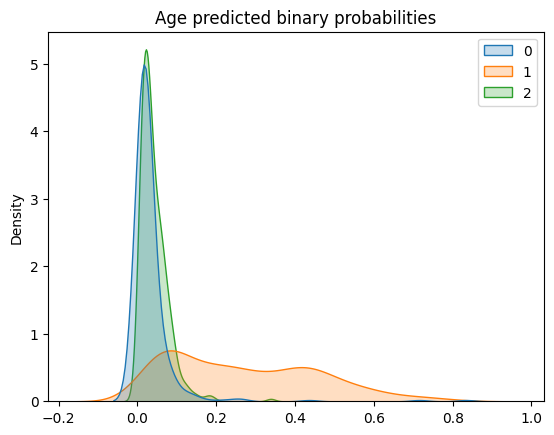

In [76]:
sns.kdeplot(c_probs[:,4:7], fill=True)
plt.title("Age predicted binary probabilities")
plt.show()

In [68]:
np.set_printoptions(suppress=True)
c_probs[0]

array([0.01667699, 0.13563168, 0.10537605, 0.10306105, 0.01320366,
       0.23942561, 0.05679476, 0.9999896 , 0.0022434 , 0.00200961,
       0.00023376, 0.00230102, 0.00001122, 0.00000114, 0.00498026,
       0.0046209 , 0.00068757], dtype=float32)

In [59]:
c_probs = np.concatenate(
    list(map(lambda x: torch.nn.Sigmoid()(x[0]), batch_results)),
    axis=0,
)

In [43]:
c_embs_state = np.concatenate(
    list(map(lambda x: x[5].detach().cpu().numpy(), 
             batch_results)),
    axis=0,
)

In [ ]:
c_probs = get_cptprobs(batch_results)

In [45]:
np.save('/SAN/colcc/Hormad1/bin_c_probs.npy', c_probs)  
np.save('/SAN/colcc/Hormad1/bin_c_embs.npy', c_embs_state)
np.save('/SAN/colcc/Hormad1/bin_c_test.npy', c_test)
np.save('/SAN/colcc/Hormad1/bin_y_test.npy', y_test)

In [ ]:
a_text = 'attention' if attention is not None else 'att_'+str(None)
name = str(pre) + '_' + str(emb_size) + '_' + str(c_weight) + '_' + str(dropout) + '_' + a_text + '_' + str(i)
names.append(name)

In [ ]:
logger1 = TensorBoardLogger(LOGS_PATH, name=name)
cem_model = ConceptEmbeddingModel(
  n_concepts=17, 
  #concept_states = [4, 4],
  n_tasks=1, 
  h_dim = 1024,
  pre_bn_mlp = pre,
  emb_size=emb_size, 
  embedding_activation="LeakyReLU",
  concept_loss_weight=c_weight,
  task_loss_weight = 1 ,
  concept_class_weights=torch.ones(len(cpt_class_weights)),
  dropout = dropout,
  learning_rate=1e-3,  
  optimizer="adam", 
  c2y_model=None, 
  attention_hook = attention_hook
) 

trainer = pl.Trainer(
    accelerator="gpu",
    devices="auto", 
    max_epochs=30,
    check_val_every_n_epoch=5,
    callbacks = [atten_callback],
    enable_progress_bar=True,
    logger=logger1
)

trainer.fit(cem_model, train_dloader, val_dloader)

In [ ]:
x_test, y_test, c_test = [], [], []
for (x, y, c) in val_dloader:
    x_test.append(x)
    y_test.append(y)
    c_test.append(c)

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
c_test = np.concatenate(c_test, axis=0)

trainer_pred = pl.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=False,
)



In [ ]:
batch_results = trainer_pred.predict(cem_model, val_dloader)

y_probs = np.concatenate(
list(
    map(
        lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), 
         batch_results)),
    axis=0,
)

c_embs = np.concatenate(
    list(map(lambda x: x[1].detach().cpu().numpy(), 
             batch_results)),
    axis=0,
)

c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))

c_probs = np.concatenate(
    list(map(lambda x: x[0], batch_results)),
    axis=0,
)

print(df)

In [ ]:
task_accuracy = accuracy_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

f1 = f1_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task f1 is {f1*100:.2f}%")

roc = roc_auc_score(y_test, y_probs)
print(f"Our CEM's test task auc_roc is {roc*100:.2f}%")

In [ ]:
t_accs.append(task_accuracy)
t_f1s.append(f1)
t_rocs.append(roc)

idx = 0
c_f1s, c_accuracies, idx = [], [], 0
for i, n in enumerate(range(c_probs.shape[-1])):
    cpt_probs = c_probs[:,i]
    cpt_probs = torch.tensor(cpt_probs)
    cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
    c = c_test[:, i]

    c_accuracies.append(
        accuracy_score(cpt_pred>=0.5, c)
        )

    c_f1s.append(f1_score(
        c,
        cpt_pred>0.5,
    ))

In [ ]:
c_avg_f1 = np.mean(c_f1s)
c_avg_accuracy = np.mean(c_accuracies)

c_f1s_lst.append(c_avg_f1 )
c_accs_lst.append(c_avg_accuracy)



In [ ]:
#print('f1: ',c_avg_f1, 'c acc:', c_avg_accuracy)
#print('f1: ',c_f1s, 'c acc:', c_accuracies)

#reshaped_tensor = c_embs.reshape(-1, 16)
#num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
#num_concepts = 17
#labels = np.tile(np.arange(num_concepts), num_parts)
#tsne = TSNE(n_components=2, random_state=42)
#tsne_results = tsne.fit_transform(reshaped_tensor)

#fig = plt.figure(figsize=(8, 6))
#for group in range(17):
 #   idx = labels == group
    #plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=f'Group {group + 1}', alpha=0.6)

#plt.show()
#fig.savefig(os.path.join(OUT_PATH, name+'.png'), dpi=fig.dpi)

In [36]:
c_states = np.concatenate(
list(
    map(
        lambda x: x[5].detach().cpu().numpy(), 
         batch_results)),
    axis=0,
)

In [42]:
c_f1s

[0.21818181818181817,
 0.38271604938271603,
 0.2638888888888889,
 0.47761194029850745,
 0.45,
 0.4274193548387097,
 0.36585365853658536,
 0.965034965034965,
 0.9056603773584906,
 0.9494949494949495,
 0.8888888888888888,
 0.9814814814814815,
 0.8387096774193549,
 0.8571428571428571,
 0.8225806451612904,
 0.9333333333333333,
 0.0]

In [34]:
cpt_pred

array([0.13702099, 0.39801097, 0.48224482, 0.44825903, 0.29259402,
       0.21381515, 0.32226107, 0.59914654, 0.4852956 , 0.36139992,
       0.7764469 , 0.6411201 , 0.49415883, 0.4923648 , 0.56853616,
       0.4975669 , 0.32421455, 0.03020094, 0.44894782, 0.32644624,
       0.18070793, 0.2431515 , 0.771146  , 0.577376  , 0.1099838 ,
       0.5066504 , 0.2548807 , 0.2762727 , 0.42591426, 0.18445165,
       0.68717223, 0.41991422, 0.0464698 , 0.57288677, 0.6344131 ,
       0.52520645, 0.6462697 , 0.1490578 , 0.48137444, 0.50807315,
       0.54802936, 0.6165104 , 0.4078789 , 0.45539474, 0.3149535 ,
       0.54833573, 0.43917087, 0.579106  , 0.6921876 , 0.49357924,
       0.47412455, 0.22657089, 0.54379535, 0.08628584, 0.4038786 ,
       0.26086938, 0.03207349, 0.47548914, 0.09859812, 0.38552034,
       0.4830962 , 0.25907236, 0.18312865, 0.13122112, 0.07778898,
       0.2822018 , 0.31282666, 0.18038635, 0.09264285, 0.18227649,
       0.45903367, 0.7580946 , 0.57511157, 0.5234641 , 0.46145

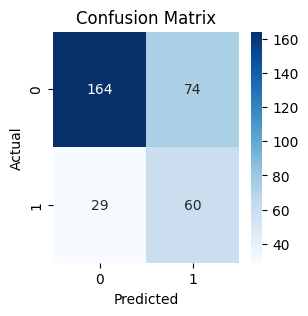

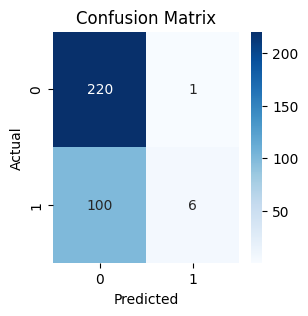

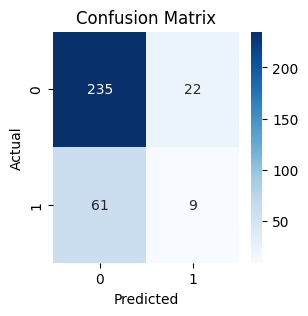

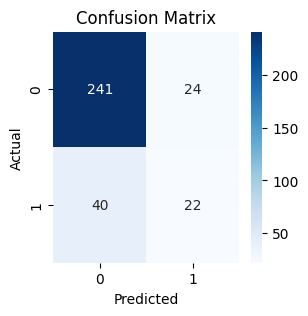

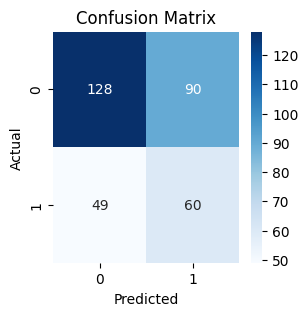

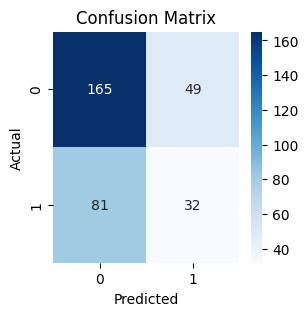

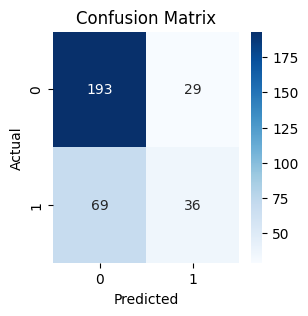

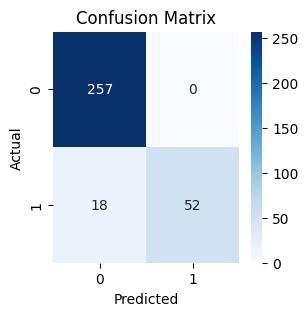

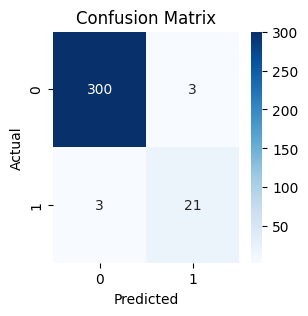

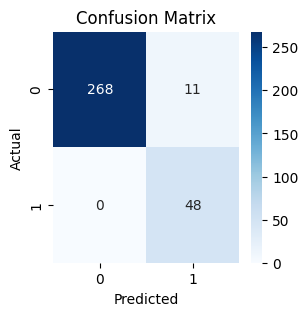

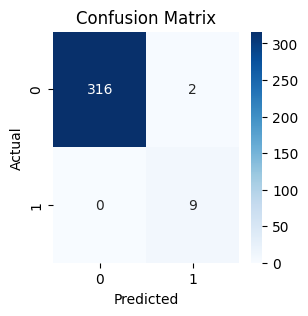

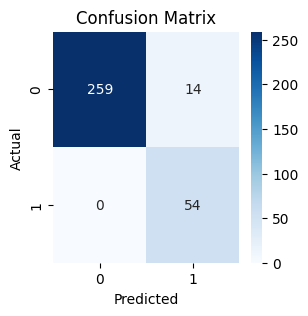

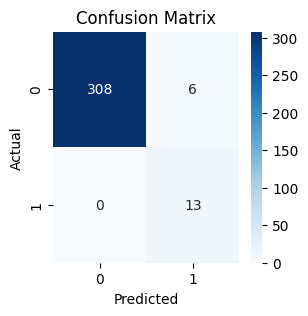

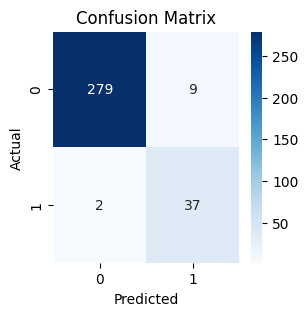

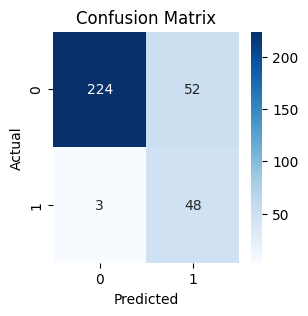

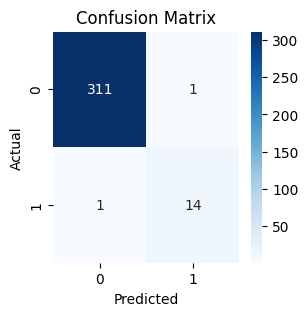

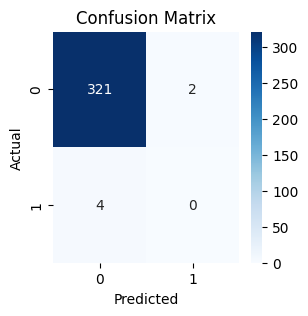

In [36]:
for i, n in enumerate(range(c_probs.shape[-1])):
        cpt_probs = c_probs[:,i]
        cpt_probs = torch.tensor(cpt_probs)
        cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
        c = c_test[:, i]

        c_accuracies.append(
            accuracy_score(cpt_pred>=0.5, c)
            )

        c_f1s.append(f1_score(
            c,
            cpt_pred>0.5,
        ))

        cm = confusion_matrix(c, cpt_pred>0.5)

        plt.figure(figsize=(3,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

In [25]:
c_f1s

[0.5381165919282511,
 0.10619469026548672,
 0.1782178217821782,
 0.4074074074074074,
 0.46332046332046334,
 0.32989690721649484,
 0.4235294117647059,
 0.8524590163934426,
 0.875,
 0.897196261682243,
 0.9,
 0.8852459016393442,
 0.8125,
 0.8705882352941177,
 0.6357615894039735,
 0.9333333333333333,
 0.0]

In [30]:
from sklearn.metrics import confusion_matrix

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt




In [26]:
np.mean([0.8524590163934426,
 0.875,
 0.897196261682243,
 0.9,
 0.8852459016393442,
 0.8125,
 0.8705882352941177,
 0.6357615894039735,
 0.9333333333333333,
 0.0])

0.7662084337746455

In [ ]:
repeated_y_test = np.repeat(y_test, 17)
repeated_c_test = np.repeat(c_test_flat, 17)

In [ ]:
reshaped_tensor = c_embs.reshape(-1, 16)
num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
num_concepts = 7
labels = np.tile(np.arange(num_concepts), num_parts)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(reshaped_tensor)

In [78]:
np.unique(repeated_c_test)

array([0, 1, 2, 3])

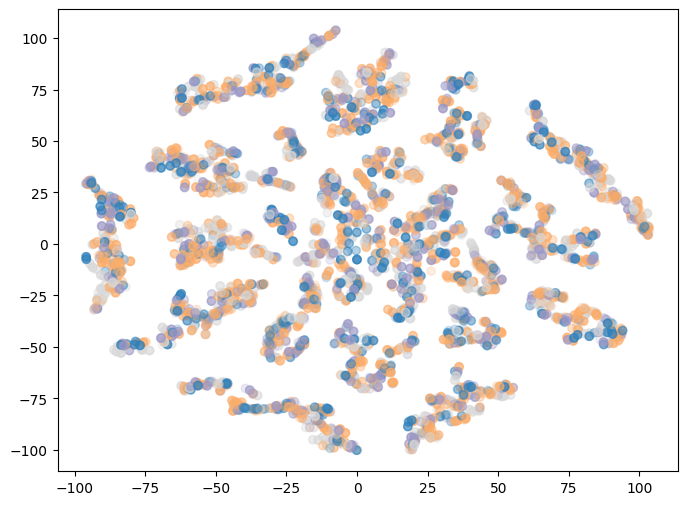

In [76]:
fig = plt.figure(figsize=(8, 6))
#for group in range(17):
    #idx = labels == group
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=repeated_c_test,cmap='tab20c', alpha=0.2)

#plt.show()
#fig.savefig(os.path.join(OUT_PATH, name+'.png'), dpi=fig.dpi)

In [ ]:
logger1 = TensorBoardLogger(LOGS_PATH, name='binary_newf1')

In [ ]:
#attention callback to log attention
attention_hook = utils.AttentionHook()
atten_callback = utils.SaveAttentionCallback(
    attention_hook=attention_hook
)

cem_model = ConceptEmbeddingModel(
  n_concepts=17, 
  #concept_states = [4, 3, 10],
  n_tasks=1, 
  h_dim = 1024,
  pre_bn_mlp = True,
  emb_size=16, 
  concept_loss_weight=1,
  learning_rate=1e-3,
  dropout = 0.3,
  optimizer="adam", 
  c_extractor_arch=None, 
  c2y_model=None, 
  attention_hook = attention_hook
)

In [ ]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices="auto", 
    max_epochs=30,
    check_val_every_n_epoch=1,
    callbacks = [RichProgressBar(), atten_callback],
    enable_progress_bar=True,
    logger=logger1
)

trainer.fit(cem_model, train_dloader, val_dloader)

### http://localhost:6008/### Evaluation

In [26]:
from sklearn.metrics import accuracy_score, auc, f1_score

In [27]:
x_test, y_test, c_test = [], [], []
for (x, y, c) in val_dloader:
    x_test.append(x)
    y_test.append(y)
    c_test.append(c)
    
x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
c_test = np.concatenate(c_test, axis=0)

Dataset length: 544


In [28]:
concept_states = [4, 4]

In [29]:
trainer_pred = pl.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=False,
)

batch_results = trainer_pred.predict(cem_model, val_dloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset length: 544
Dataset length: 544
Dataset length: 544
Dataset length: 544


Predicting: |          | 0/? [00:00<?, ?it/s]

Dataset length: 544


In [30]:
y_probs = np.concatenate(
    list(
        map(
            lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), 
             batch_results)),
    axis=0,
)

c_embs = np.concatenate(
    list(map(lambda x: x[1].detach().cpu().numpy(), 
             batch_results)),
    axis=0,
)

c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))

c_probs = np.concatenate(
    list(map(lambda x: x[0], batch_results)),
    axis=0,
)

In [43]:
##########
## Compute test task accuracy
##########

from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score

task_accuracy = accuracy_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

##########
## Compute test task F1
##########

from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score

f1 = f1_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task f1 is {f1*100:.2f}%")

##########
## Compute test task ROC
##########

from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score, roc_auc_score

roc = roc_auc_score(y_test, y_probs)
print(f"Our CEM's test task auc_roc is {roc*100:.2f}%")

Our CEM's test task accuracy is 53.39%
Our CEM's test task f1 is 66.83%
Our CEM's test task auc_roc is 48.88%


In [45]:
np.set_printoptions(suppress=True, precision=6)

In [31]:
c_pred = c_probs
c_true = c_test

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [44]:
cpt_probs = torch.tensor(c_probs)
c_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
c_pred = c_pred > 0.5
c_pred

array([[False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False]])

In [49]:
cpt_probs = torch.tensor(c_probs)
c_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
c_pred = c_pred > 0.5
c_true = c_test
c_accuracy = c_auc = c_f1 = 0
num_seen = 0
for i in range(c_true.shape[-1]):
    true_vars = c_true[:, i]
    indices = np.logical_or(true_vars == 1, true_vars == 0).astype(bool)
    if not np.any(indices):
        continue
    num_seen += 1
    true_vars = true_vars[indices]
    pred_vars = c_pred[:, i][indices]
    c_accuracy += accuracy_score(
        true_vars,
        pred_vars,
    )
    if len(np.unique(true_vars)) == 1:
        c_auc += accuracy_score(true_vars,  pred_vars)
    else:
        c_auc += roc_auc_score(
            true_vars,
            pred_vars,
        )
    c_f1 += f1_score(
        true_vars,
        pred_vars,
        average='macro',
    )
num_seen = num_seen if num_seen else 1
c_accuracy = c_accuracy/num_seen
c_auc = c_auc/num_seen
c_f1 = c_f1/num_seen

In [50]:
c_f1

0.4929161303858417

In [ ]:
idx = 0
c_f1s, c_accuracies, idx = [], [], 0
for i, n in enumerate(range(c_probs.shape[-1])):
    cpt_probs = c_probs[:,i]
    cpt_probs = torch.tensor(cpt_probs)
    cpt_pred = torch.nn.Sigmoid()(cpt_probs).cpu().numpy()
    c = c_test[:, i]
    
    c_accuracies.append(
        accuracy_score(cpt_pred>=0.5, c)
        )

    c_f1s.append(f1_score(
        c,
        cpt_pred>0.5,
    ))

c_avg_f1 = np.mean(c_f1s)
c_avg_accuracy = np.mean(c_accuracies)

print('f1: ',c_avg_f1, 'c acc:', c_avg_accuracy)
print('f1: ',c_f1s, 'c acc:', c_accuracies)

In [56]:
c_embs.shape
num_parts
reshaped_tensor.shape
reshaped_tensor.shape[0]/c_embs.shape[1]

reshaped_tensor = c_embs.reshape(-1, 16)
num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
num_concepts = 17

590.0

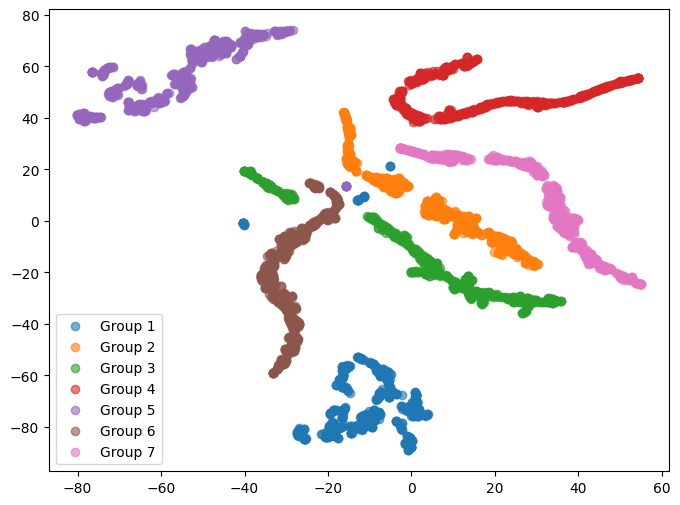

In [57]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

reshaped_tensor = c_embs.reshape(-1, 16)
num_parts = int(reshaped_tensor.shape[0]/c_embs.shape[1])
num_concepts = 17
labels = np.tile(np.arange(num_concepts), num_parts)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(reshaped_tensor)

plt.figure(figsize=(8, 6))
for group in range(7):
    idx = labels == group
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=f'Group {group + 1}', alpha=0.6)

#plt.title("t-SNE of Concept embeddings")
plt.legend()
#plt.show()

In [42]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

reshaped_tensor = c_embs.reshape(-1, 8)
labels = np.repeat(np.arange(7), 79)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(reshaped_tensor)

plt.figure(figsize=(8, 6))
for group in range(7):
    idx = labels == group
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=f'Group {group + 1}', alpha=0.6)

#plt.title("t-SNE of Concept embeddings")
plt.legend()
#plt.show()

IndexError: boolean index did not match indexed array along dimension 0; dimension is 1078 but corresponding boolean dimension is 553

<Figure size 800x600 with 0 Axes>

In [43]:
def inspect_logits(model, data_loader):
    """
    Inspects and visualizes logit ranges from the model's output during evaluation.

    Args:
        model: The trained model.
        data_loader: Validation or test data loader.
    """
    model.eval()
    state_logits = []
    y_logits = []
    
    with torch.no_grad():
        for batch in data_loader:
            (x, y, c) = batch
            state_logit, cpt_embedds, y_logit, concept_states = model(x)
            state_logits.append(state_logit.cpu()) 
            y_logits.append(y_logit.cpu())

    state_logits = torch.cat(state_logits, dim=0)
    y_logits = torch.cat(y_logits, dim=0)
    
    # Print statistics
    print(f"State Logits - Min: {state_logits.min().item()}, Max: {state_logits.max().item()}, "
          f"Mean: {state_logits.mean().item()}, Std: {state_logits.std().item()}")
    
    print(f"Y Logits - Min: {y_logits.min().item()}, Max: {y_logits.max().item()}, "
          f"Mean: {y_logits.mean().item()}, Std: {y_logits.std().item()}")
    
    # Plot histogram of logits
    fig, axes = plt.subplots(1,2,figsize=(15,4))
    axes[0].hist(state_logits.numpy().flatten(), bins=50, alpha=0.7, color='blue')
    axes[1].hist(y_logits.numpy().flatten(), bins=50, alpha=0.7, color='red')
    #plt.title("Logit Distribution")
    #plt.xlabel("Logit Value")
    #plt.ylabel("Frequency")
    #plt.grid(True)
    plt.show()


Dataset length: 77
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 40

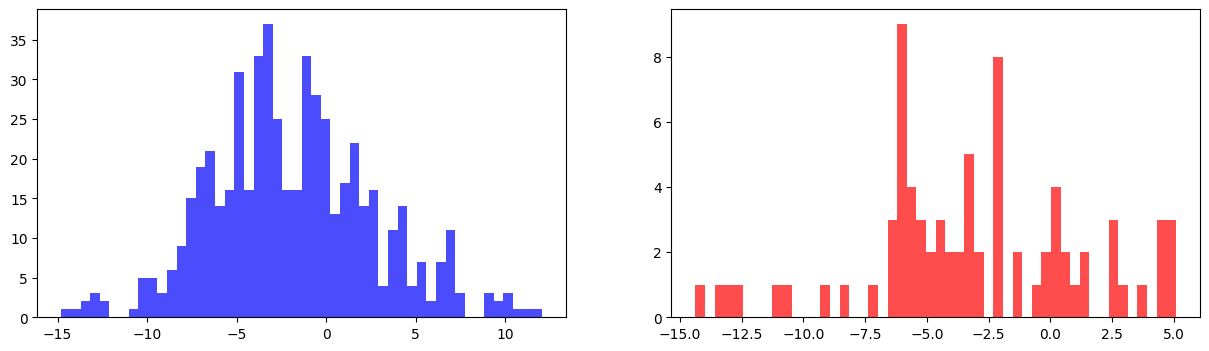

In [44]:
#bnx
inspect_logits(cem_model, val_dloader)

Dataset length: 77
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 4096])
h attention torch.Size([4, 40

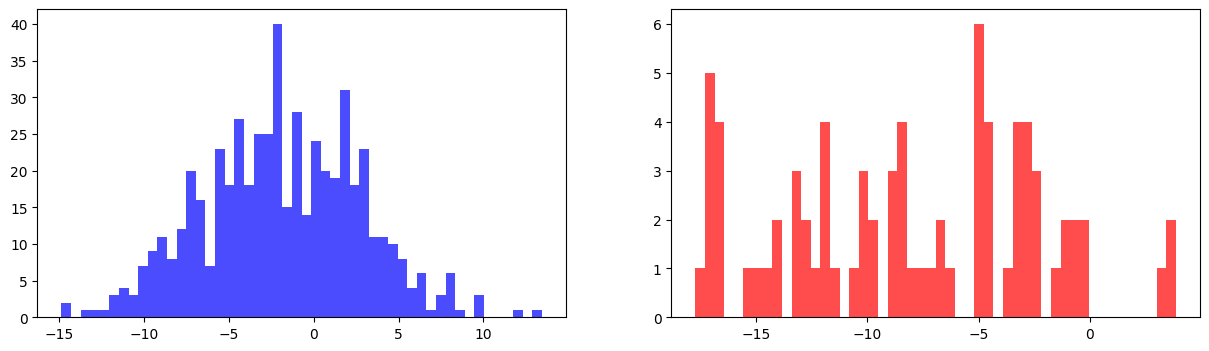

In [32]:
#bnx
inspect_logits(cem_model, val_dloader)

Dataset length: 81
State Logits - Min: -11.654417037963867, Max: 6.6210618019104, Mean: -2.2475368976593018, Std: 3.4176185131073
Y Logits - Min: -12.294723510742188, Max: 6.154377460479736, Mean: -2.467721700668335, Std: 4.00169563293457


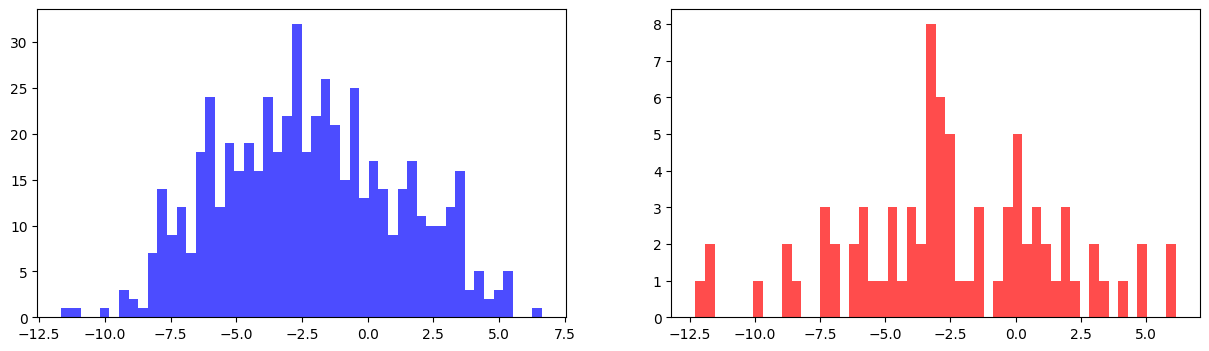

In [62]:
#mean
inspect_logits(cem_model, val_dloader)

Dataset length: 81
State Logits - Min: -3151.2744140625, Max: 244.54110717773438, Mean: -25.118066787719727, Std: 145.32798767089844
Y Logits - Min: -369.6800231933594, Max: 20.61551284790039, Mean: -33.76313400268555, Std: 60.62318801879883


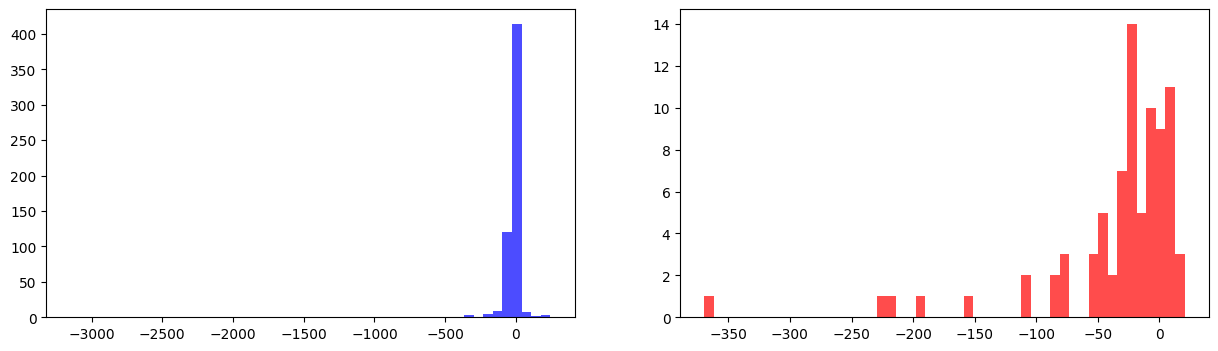

In [48]:
#attention
inspect_logits(cem_model, val_dloader)

In [ ]:
c_embs = np.concatenate(
    list(map(lambda x: x[1].detach().cpu().numpy(), 
             batch_results)),
    axis=0,
)

c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))

c_probs = np.concatenate(
    list(map(lambda x: x[0], batch_results)),
    axis=0,
)

In [ ]:
f1:  0.5570170721776037 c acc: 0.7231040564373897 c roc_auc: 0.5570170721776037
f1:  [0.7436708860759493, 0.4527027027027027, 0.5333333333333333, 0.49920508744038156, 0.5033576642335766, 0.5868026987000164, 0.5800471327572663] c acc: [0.9753086419753086, 0.8271604938271605, 0.7407407407407407, 0.5679012345679012, 0.7407407407407407, 0.6172839506172839, 0.5925925925925926]
        
Our CEM's test task accuracy is 69.14%
Our CEM's test task f1 is 46.81%
Our CEM's test task auc_roc is 64.32%


f1:  0.5264495316218486 c acc: 0.746031746031746 c roc_auc: 0.5264495316218486

f1:  [0.4968944099378882, 0.4452054794520548, 0.4295774647887324, 0.5319722650231125, 0.5108695652173914, 0.6341935483870967, 0.6364339885466646] c acc: [0.9876543209876543, 0.8024691358024691, 0.7530864197530864, 0.6296296296296297, 0.7530864197530864, 0.654320987654321, 0.6419753086419753]
        Our CEM's test task accuracy is 70.37%
Our CEM's test task f1 is 55.56%
Our CEM's test task auc_roc is 63.68%

In [ ]:
def balance_features(df, id_column):

    feature_columns = [col for col in df.columns if col != id_column]
    
    imbalance_ratios = {
        feature: min(
            df[feature].value_counts().get(1, 0),  
            df[feature].value_counts().get(0, 0)  
        )
        for feature in feature_columns
    }
    

    sorted_features = sorted(imbalance_ratios, key=imbalance_ratios.get, reverse=True)
    balanced_ids = None
    
    for feature in sorted_features:
        positive_ids = df[df[feature] == 1][id_column]
        negative_ids = df[df[feature] == 0][id_column]
        
        min_size = min(len(positive_ids), len(negative_ids))
        
        sampled_positive_ids = positive_ids.sample(n=min_size, random_state=42)
        sampled_negative_ids = negative_ids.sample(n=min_size, random_state=42)
        
        feature_balanced_ids = pd.concat([sampled_positive_ids, sampled_negative_ids])
        
        if balanced_ids is None:
            balanced_ids = set(feature_balanced_ids)
        else:
            balanced_ids &= set(feature_balanced_ids)
        #print(len(balanced_ids))
        
        if not balanced_ids:
            break
    
    balanced_df = df[df[id_column].isin(balanced_ids)]
    
    return balanced_df

test = balance_features(pcanc_train_cohort,'ID')